библиотеки

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error,  mean_absolute_error

подгрузка датасета

In [14]:
ds = pd.read_csv('probe.csv')
ds

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830
5,51,7,41630
6,28,5,41340
7,33,4,37650
8,37,5,40250
9,39,8,45150


распределения признаков

<Axes: >

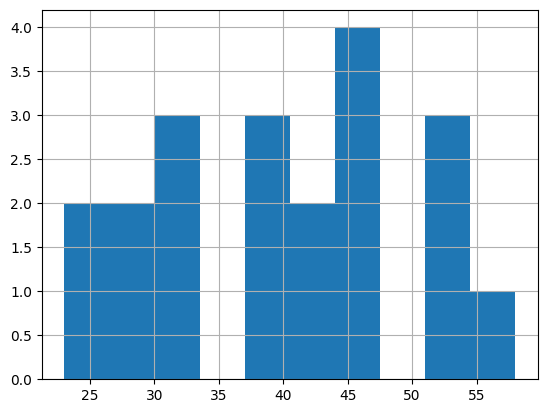

In [15]:
ds['age'].hist(bins=10)

<Axes: >

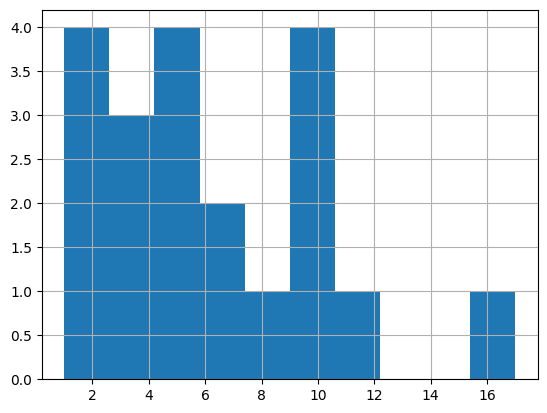

In [16]:
ds['experience'].hist(bins=10)

выбросы

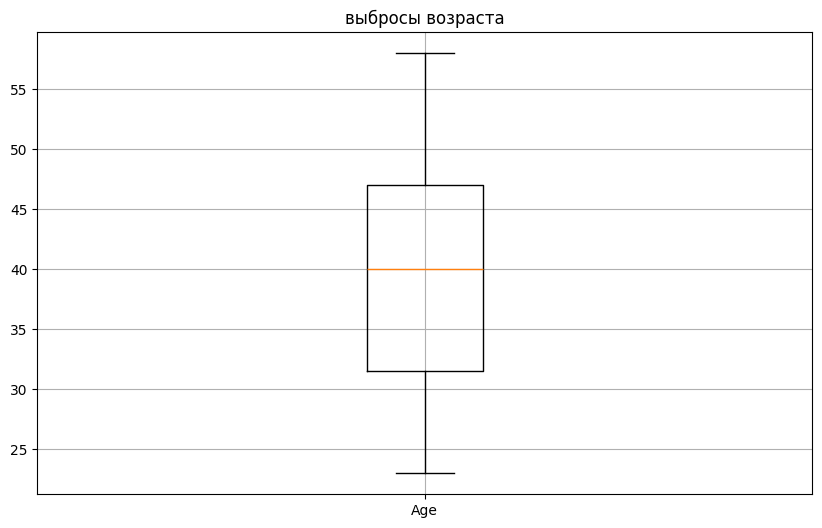

In [17]:
plt.figure(figsize=(10, 6))
plt.boxplot([ds['age']], tick_labels=['Age'])
plt.title('выбросы возраста')
plt.grid(True)
plt.show()

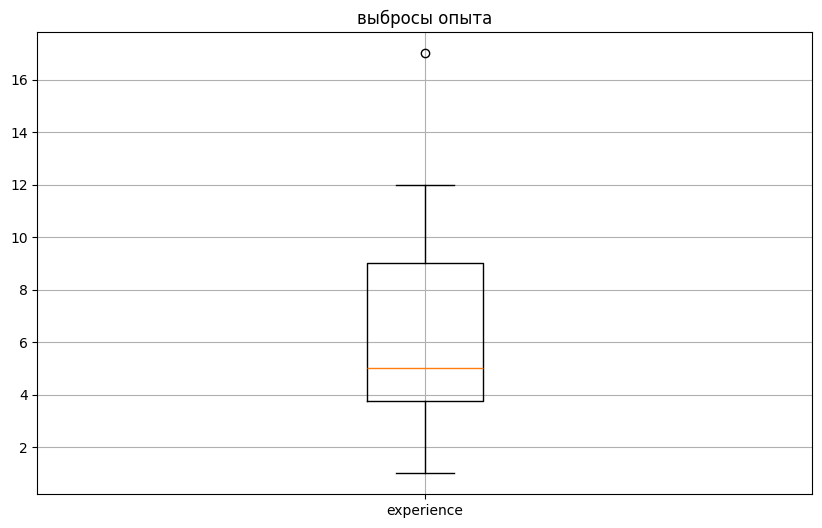

In [18]:
plt.figure(figsize=(10, 6))
plt.boxplot([ds['experience']], tick_labels=['experience'])
plt.title('выбросы опыта')
plt.grid(True)
plt.show()

избавление от выбросов

In [19]:
cols = ['age', 'experience']
mask = (ds[cols] - ds[cols].mean()).abs() <= (3 * ds[cols].std())
ds_clean = ds[mask.all(axis=1)]

разделение на признаки

In [20]:
x = ds[['age', 'experience']]
y = ds['income']
x_clear = ds_clean[['age', 'experience']].reset_index(drop=True)
y_clear = ds_clean['income'].reset_index(drop=True)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)
xc_train, xc_test, yc_train, yc_test = train_test_split(x_clear, y_clear, test_size=0.4, random_state=42)
ds.corr()

,age,experience,income
age,1.000000,0.615165,0.532204
experience,0.615165,1.000000,0.984227
income,0.532204,0.984227,1.000000


In [21]:
model = LinearRegression()
model.fit(xc_train, yc_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


метрики

In [22]:
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

yc_pred = model.predict(xc_test)
mse_c = mean_squared_error(yc_test, yc_pred)
r2_c = r2_score(yc_test, yc_pred)
mae_c = mean_absolute_error(yc_test, yc_pred)
print("с выбросами", mse**0.5, r2, mae)
print("без выбросов", mse_c**0.5, r2_c, mae_c)

с выбросами 1115.5073496751065 0.9508709671946177 850.9347259704323
без выбросов 1115.5073496751065 0.9508709671946177 850.9347259704323


график обучения

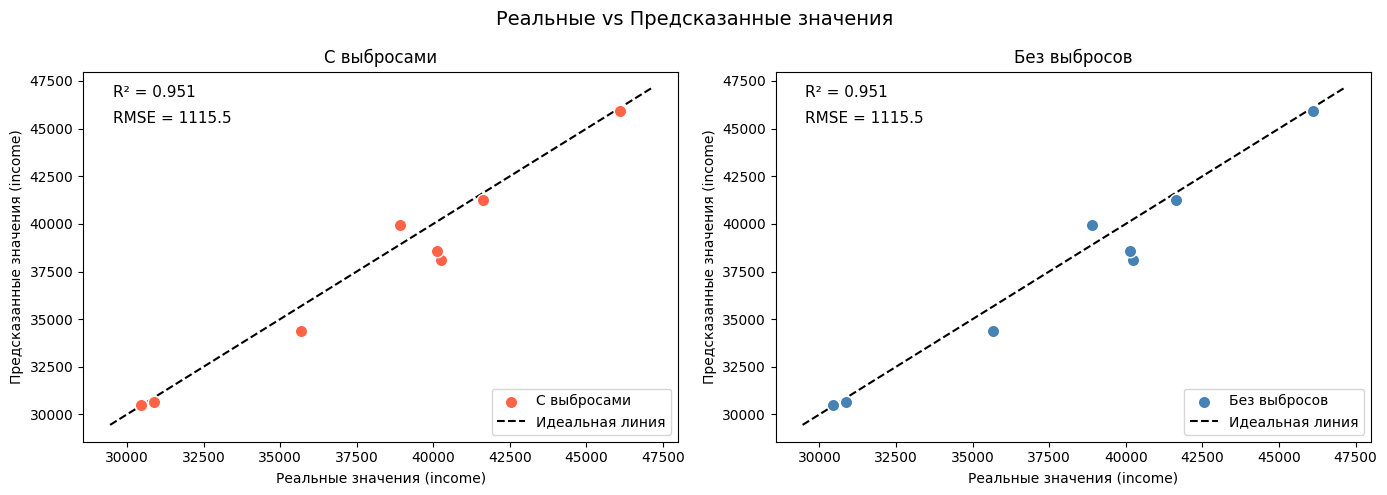

In [23]:
y_pred_dirty = model.predict(x_test)
yc_pred_clean = model.predict(xc_test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred_dirty, color='tomato', edgecolors='white', s=80, zorder=3, label='С выбросами')
lims = [min(y_test.min(), y_pred_dirty.min()) - 1000, max(y_test.max(), y_pred_dirty.max()) + 1000]
axes[0].plot(lims, lims, 'k--', linewidth=1.5, label='Идеальная линия')
axes[0].set_xlabel('Реальные значения (income)')
axes[0].set_ylabel('Предсказанные значения (income)')
axes[0].set_title('С выбросами')
axes[0].legend()
r2_dirty = r2_score(y_test, y_pred_dirty)
rmse_dirty = mean_squared_error(y_test, y_pred_dirty) ** 0.5
axes[0].text(0.05, 0.93, f'R² = {r2_dirty:.3f}', transform=axes[0].transAxes, fontsize=11)
axes[0].text(0.05, 0.86, f'RMSE = {rmse_dirty:.1f}', transform=axes[0].transAxes, fontsize=11)
axes[1].scatter(yc_test, yc_pred_clean, color='steelblue', edgecolors='white', s=80, zorder=3, label='Без выбросов')
lims = [min(yc_test.min(), yc_pred_clean.min()) - 1000, max(yc_test.max(), yc_pred_clean.max()) + 1000]
axes[1].plot(lims, lims, 'k--', linewidth=1.5, label='Идеальная линия')
axes[1].set_xlabel('Реальные значения (income)')
axes[1].set_ylabel('Предсказанные значения (income)')
axes[1].set_title('Без выбросов')
axes[1].legend()
r2_clean = r2_score(yc_test, yc_pred_clean)
rmse_clean = mean_squared_error(yc_test, yc_pred_clean) ** 0.5
axes[1].text(0.05, 0.93, f'R² = {r2_clean:.3f}', transform=axes[1].transAxes, fontsize=11)
axes[1].text(0.05, 0.86, f'RMSE = {rmse_clean:.1f}', transform=axes[1].transAxes, fontsize=11)

plt.suptitle('Реальные vs Предсказанные значения', fontsize=14)
plt.tight_layout()
plt.show()